In [21]:
# 데이터 구성:Series, DataFrame
import pandas as pd
# 행렬 연산
import numpy as np
# 데이터 시각화
import matplotlib ;  import matplotlib.pyplot as plt
# 데이터 시각화:추세, 산점도 행렬 
import seaborn as sns
# Scale 변환:평균,표준편차 기준
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 맑은 고딕 적용
matplotlib.rc("font", family = "NanumGothic")
# 음수 표시
matplotlib.rc('axes', unicode_minus=False)

In [22]:
data = pd.read_csv("/home/piai/반도체 데이터 분석/Final2_data.csv")
data.head()

,No_Die,Ox_Chamber,type,Temp_OXid,ppm,Pressure,Oxid_time,thickness,Lot_Num,Wafer_Num,...,Flux480s,Flux840s,input_Energy,Temp_implantation,Furance_Temp,RTA_Temp,Target,Error_message,Target_error,Path
0,NOLSM32513132,2,0,1214.33,26.78,0.30,120,712.98,13,28,...,3.010000e+17,6.000000e+17,30795.856,103.513,854,154,141,none,0,21111
1,NOLSM32513133,2,0,977.98,30.90,0.14,137,714.41,13,29,...,3.030000e+17,6.000000e+17,32135.659,105.628,895,156,55,none,0,21122
2,NOLSM32513134,2,0,1175.95,31.11,0.25,116,710.27,13,30,...,2.980000e+17,6.000000e+17,31057.876,102.716,898,152,96,none,0,21133
3,NOLSM32513135,2,0,933.47,31.20,0.29,143,710.62,13,31,...,3.000000e+17,6.000000e+17,32140.435,102.902,879,155,105,none,0,21111
4,NOLSM32513136,2,0,1140.60,31.38,0.20,76,711.70,13,32,...,3.020000e+17,6.000000e+17,31985.989,101.465,882,155,79,none,0,21122


In [23]:
data.tail()

,No_Die,Ox_Chamber,type,Temp_OXid,ppm,Pressure,Oxid_time,thickness,Lot_Num,Wafer_Num,...,Flux480s,Flux840s,input_Energy,Temp_implantation,Furance_Temp,RTA_Temp,Target,Error_message,Target_error,Path
14417,NOLSM32528517,3,0,1119.37,27.37,0.13,50,711.92,13,23,...,3.000000e+17,6.000000e+17,31877.793,101.566,914,155,134,none,0,32222
14418,NOLSM32528518,3,0,1263.81,31.62,0.18,112,696.98,13,24,...,3.000000e+17,6.000000e+17,30107.476,102.856,899,156,129,none,0,32311
14419,NOLSM32528519,3,0,964.04,38.56,0.08,78,706.11,13,25,...,2.990000e+17,6.000000e+17,32048.298,102.541,903,157,78,none,0,33111
14420,NOLSM32528520,3,0,1058.80,32.84,0.38,80,707.33,13,26,...,3.000000e+17,6.000000e+17,31221.150,104.359,879,155,60,none,0,33222
14421,NOLSM32528521,3,0,1046.03,44.90,0.31,89,715.99,13,27,...,3.000000e+17,6.000000e+17,31645.170,100.492,890,157,74,none,0,33333


In [24]:
data.columns

Index(['No_Die', 'Ox_Chamber', 'type', 'Temp_OXid', 'ppm', 'Pressure',
       'Oxid_time', 'thickness', 'Lot_Num', 'Wafer_Num', 'Datetime',
       'photo_soft_Chamber', 'resist_target', 'N2_HMDS', 'pressure_HMDS',
       'temp_HMDS', 'temp_HMDS_bake', 'time_HMDS_bake', 'spin1', 'spin2',
       'spin3', 'photoresist_bake', 'temp_softbake', 'time_softbake',
       'lithography_Chamber', 'Line_CD', 'Wavelength', 'Resolution',
       'Energy_Exposure', 'Etching_Chamber', 'Thin F4', 'Thin F3', 'Thin F2',
       'Thin F1', 'Temp_Etching', 'Source_Power', 'Selectivity', 'Chamber_Num',
       'Flux60s', 'Flux90s', 'Flux160s', 'Flux480s', 'Flux840s',
       'input_Energy', 'Temp_implantation', 'Furance_Temp', 'RTA_Temp',
       'Target', 'Error_message', 'Target_error', 'Path'],
      dtype='object')

## Oxidation 공정 (Temp_OXid, ppm, Pressure, Oxid_time)
### Temp_OXid 변수 운전 조건에 따른 그래프

<Figure size 400x300 with 0 Axes>

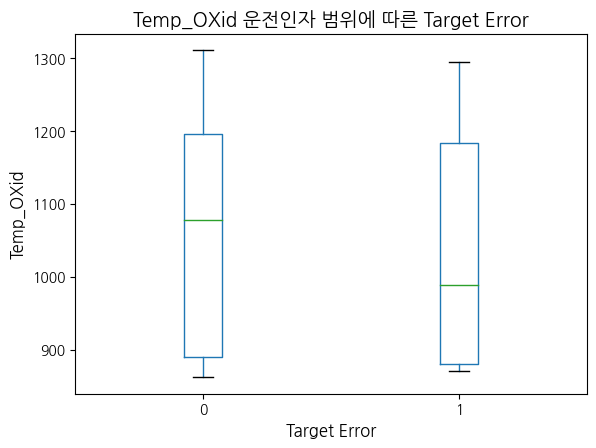

<Figure size 400x300 with 0 Axes>

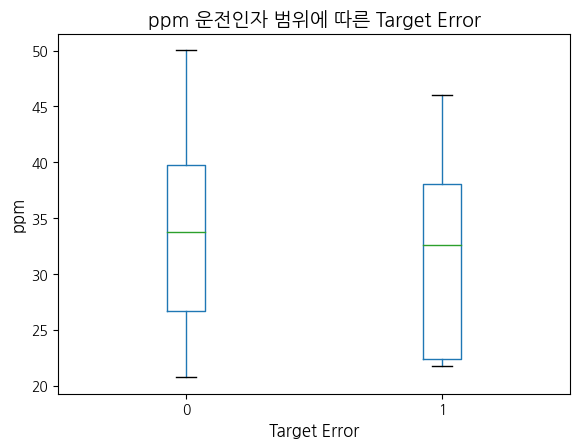

<Figure size 400x300 with 0 Axes>

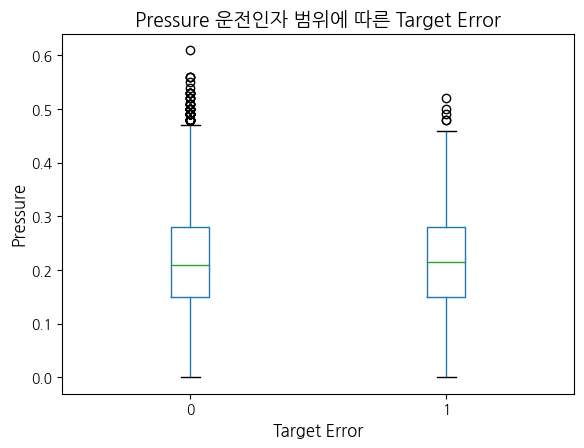

<Figure size 400x300 with 0 Axes>

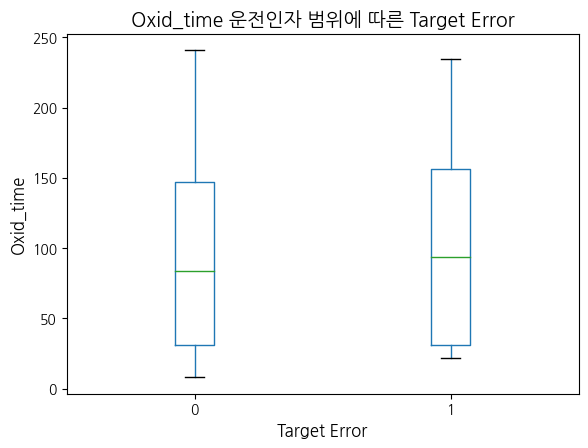

In [25]:
import matplotlib.pyplot as plt

# 분석할 연속형 변수 목록
columns_to_plot = ['Temp_OXid', 'ppm', 'Pressure', 'Oxid_time']

# 각각의 변수에 대해 Target_error에 따른 Box Plot 개별 생성
for column in columns_to_plot:
    plt.figure(figsize=(4, 3))
    data.boxplot(column=column, by='Target_error', grid=False)
    plt.title(f'{column} 운전인자 범위에 따른 Target Error', fontsize=14)  # 제목 글자 크기
    plt.suptitle('')
    plt.xlabel('Target Error', fontsize=12)  # x축 라벨 글자 크기
    plt.ylabel(column, fontsize=12)  # y축 라벨 글자 크기
    plt.xticks(fontsize=10)  # x축 눈금 글자 크기
    plt.yticks(fontsize=10)  # y축 눈금 글자 크기
    plt.show()

## Photo_softbake 공정 ('N2_HMDS', 'pressure_HMDS', 'temp_HMDS', 'temp_HMDS_bake', 'time_HMDS_bake', 'spin1', 'spin2', 'spin3', 'photoresist_bake', 'temp_softbake', 'time_softbake')
### 운전 조건에 따른 그래프

<Figure size 400x300 with 0 Axes>

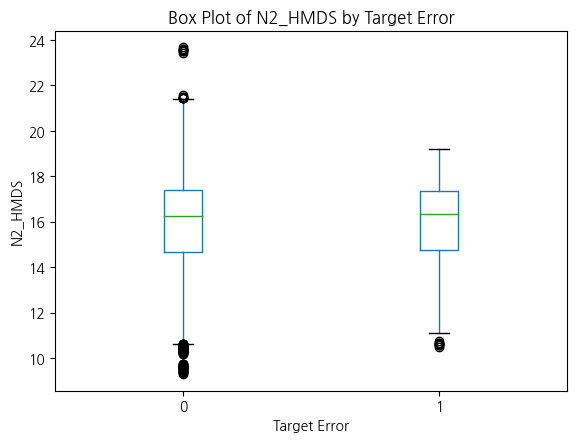

<Figure size 400x300 with 0 Axes>

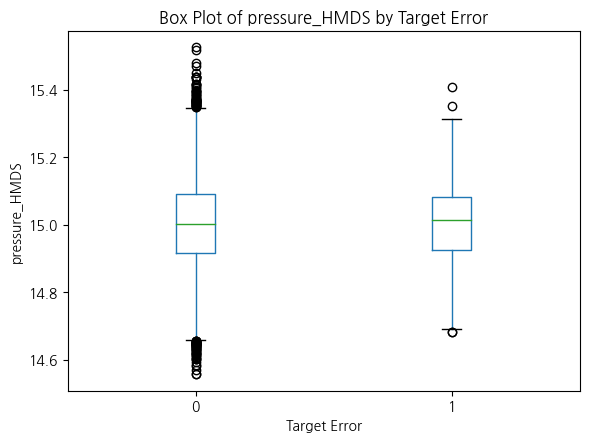

<Figure size 400x300 with 0 Axes>

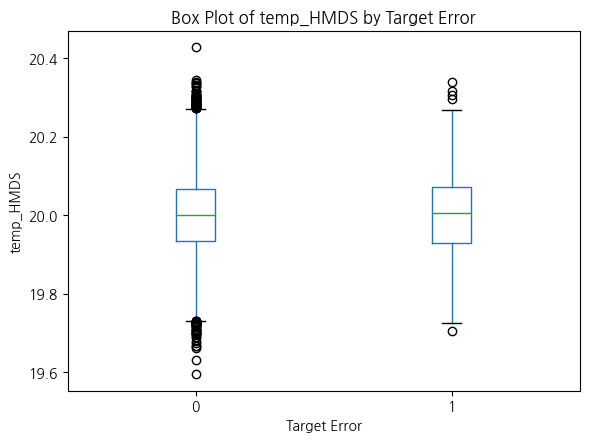

<Figure size 400x300 with 0 Axes>

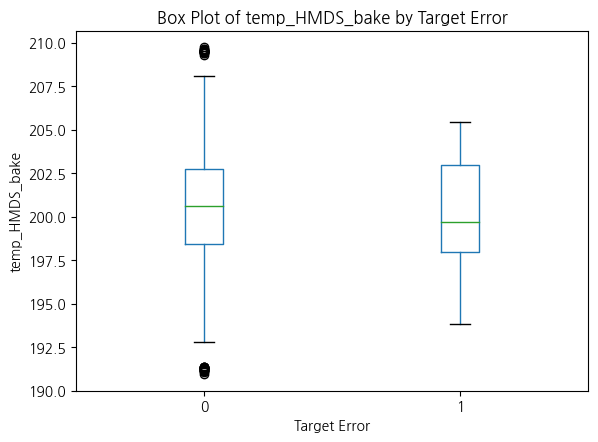

<Figure size 400x300 with 0 Axes>

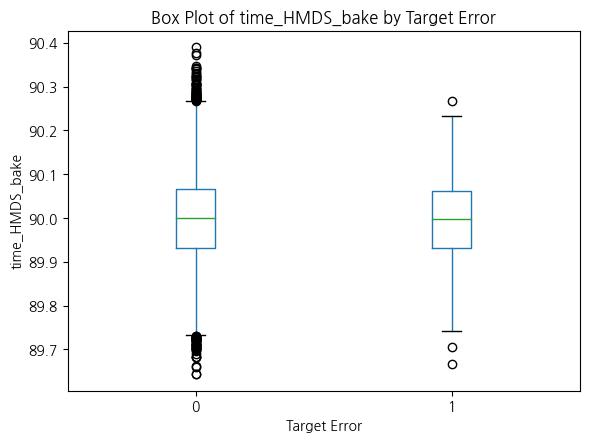

<Figure size 400x300 with 0 Axes>

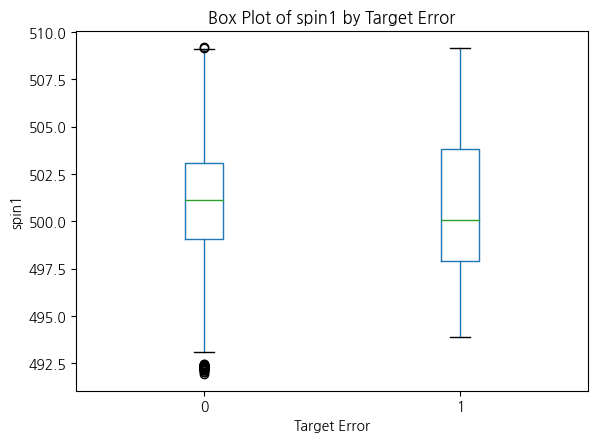

<Figure size 400x300 with 0 Axes>

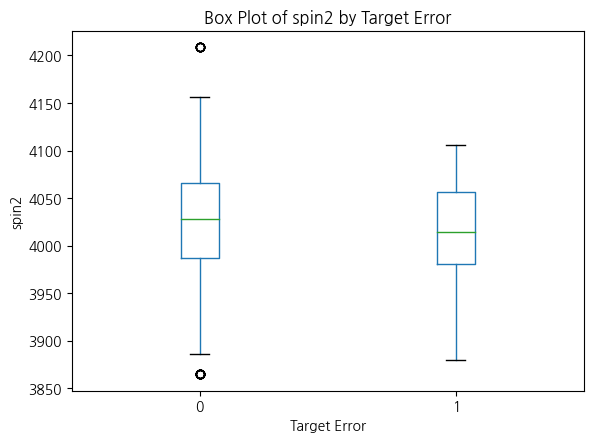

<Figure size 400x300 with 0 Axes>

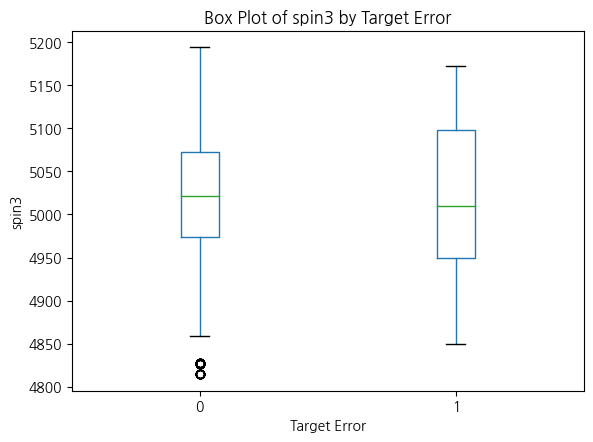

<Figure size 400x300 with 0 Axes>

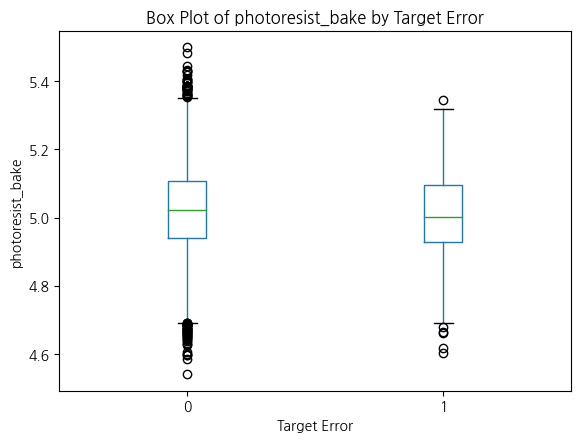

<Figure size 400x300 with 0 Axes>

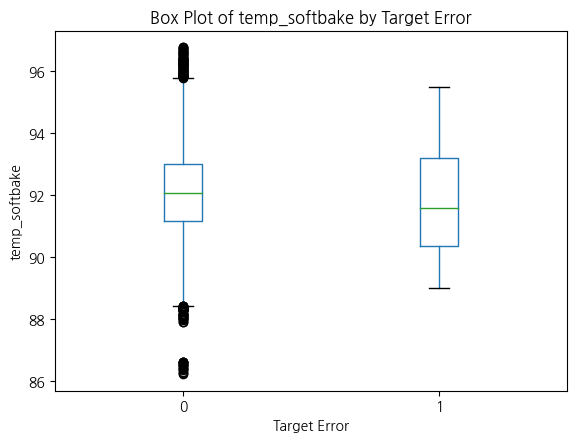

<Figure size 400x300 with 0 Axes>

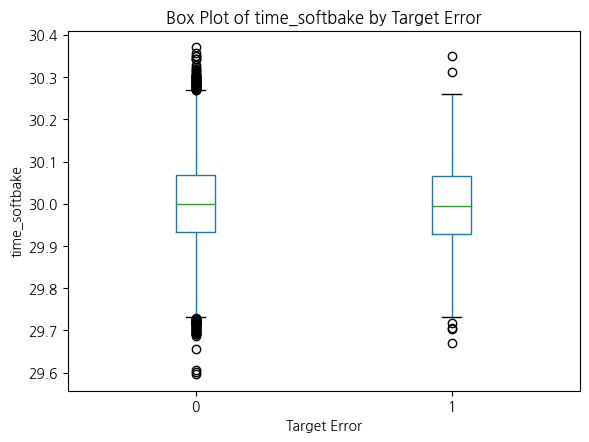

In [26]:
import matplotlib.pyplot as plt

# 분석할 연속형 변수 목록
columns_to_plot = [ 'N2_HMDS', 'pressure_HMDS', 'temp_HMDS', 'temp_HMDS_bake', 'time_HMDS_bake',
    'spin1', 'spin2', 'spin3', 'photoresist_bake', 'temp_softbake', 'time_softbake']

# 각각의 변수에 대해 Target_error에 따른 Box Plot 개별 생성
for column in columns_to_plot:
    plt.figure(figsize=(4, 3))
    data.boxplot(column=column, by='Target_error', grid=False)
    plt.title(f'Box Plot of {column} by Target Error')
    plt.suptitle('')
    plt.xlabel('Target Error')
    plt.ylabel(column)
    plt.show()

## Photo_lithography 공정 ('Wavelength', 'Resolution', 'Energy_Exposure')
### 운전 조건에 따른 box plot

<Figure size 800x600 with 0 Axes>

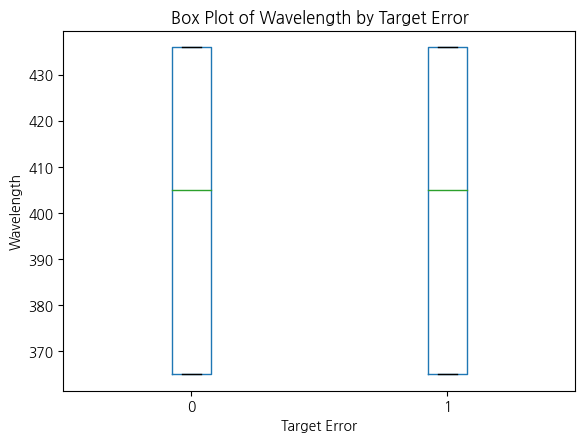

<Figure size 800x600 with 0 Axes>

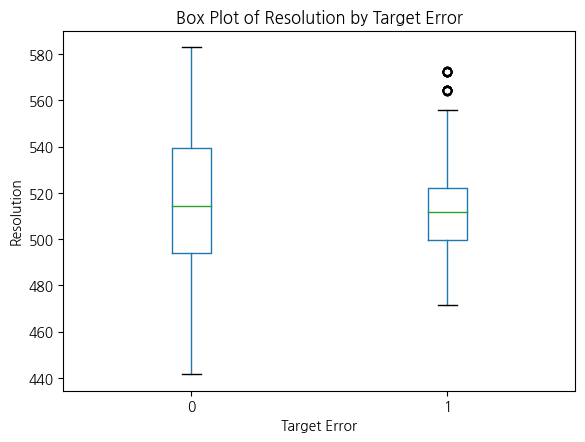

<Figure size 800x600 with 0 Axes>

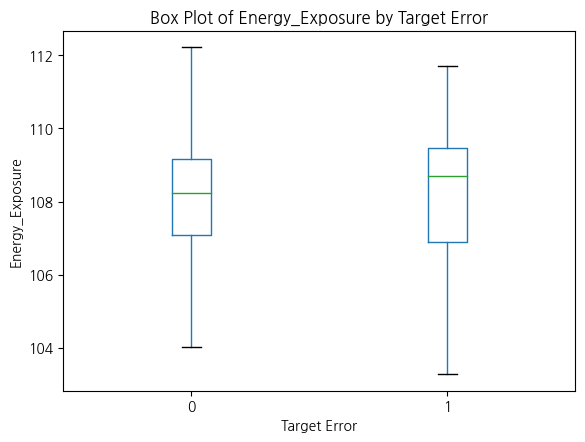

In [27]:
import matplotlib.pyplot as plt

# 분석할 연속형 변수 목록
columns_to_plot = ['Wavelength', 'Resolution', 'Energy_Exposure']

# 각각의 변수에 대해 Target_error에 따른 Box Plot 개별 생성
for column in columns_to_plot:
    plt.figure(figsize=(8, 6))
    data.boxplot(column=column, by='Target_error', grid=False)
    plt.title(f'Box Plot of {column} by Target Error')
    plt.suptitle('')
    plt.xlabel('Target Error')
    plt.ylabel(column)
    plt.show()

## Eching 공정 ('Temp_Etching','Source_Power','Selectivity')
### 운전 조건에 따른 box plot

<Figure size 800x600 with 0 Axes>

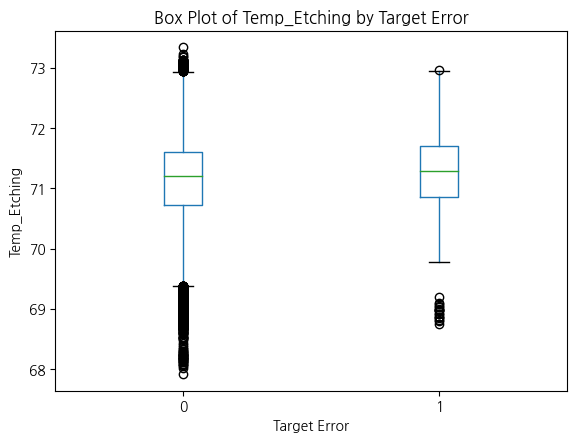

<Figure size 800x600 with 0 Axes>

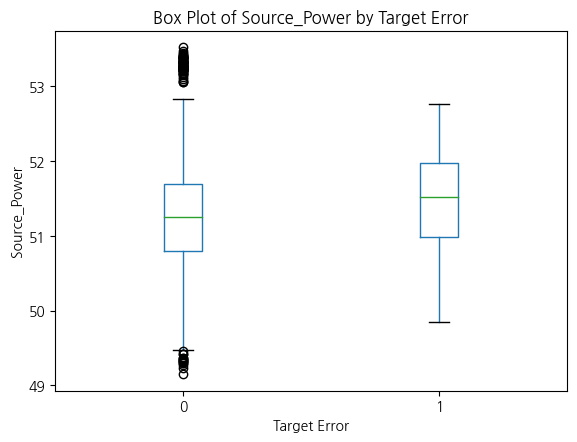

<Figure size 800x600 with 0 Axes>

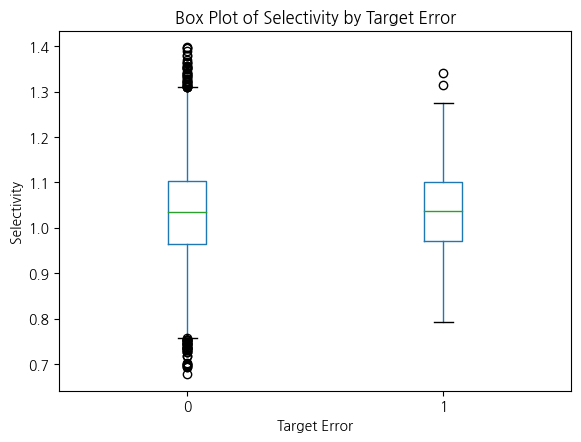

In [28]:
# 분석할 연속형 변수 목록
columns_to_plot = ['Temp_Etching','Source_Power','Selectivity']

# 각각의 변수에 대해 Target_error에 따른 Box Plot 개별 생성
for column in columns_to_plot:
    plt.figure(figsize=(8, 6))
    data.boxplot(column=column, by='Target_error', grid=False)
    plt.title(f'Box Plot of {column} by Target Error')
    plt.suptitle('')
    plt.xlabel('Target Error')
    plt.ylabel(column)
    plt.show()

## Ion Implantation 공정('Flux60s','Flux90s','Flux160s','Flux480s','Flux840s','input_Energy','Temp_implantation','Furance_Temp','RTA_Temp')
### 운전 조건에 따른 box plot

<Figure size 400x300 with 0 Axes>

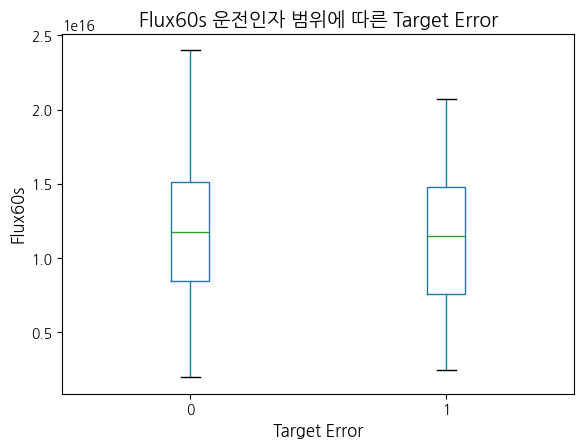

<Figure size 400x300 with 0 Axes>

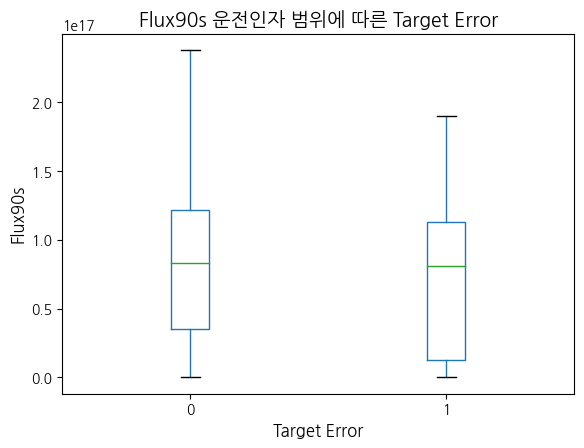

<Figure size 400x300 with 0 Axes>

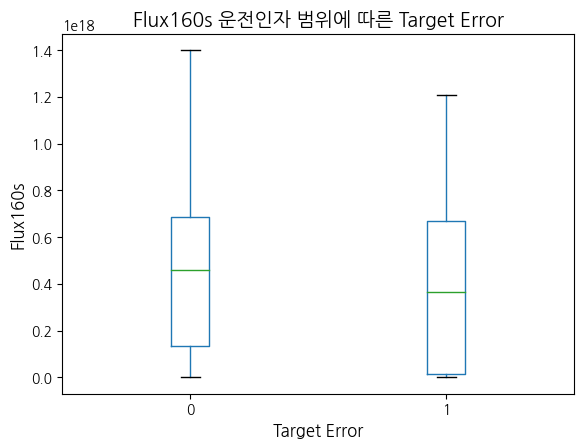

<Figure size 400x300 with 0 Axes>

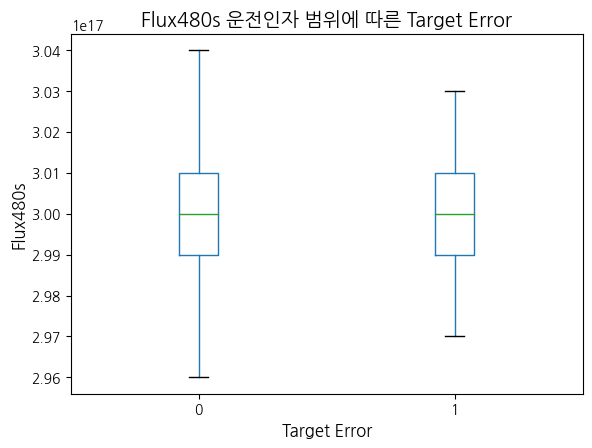

<Figure size 400x300 with 0 Axes>

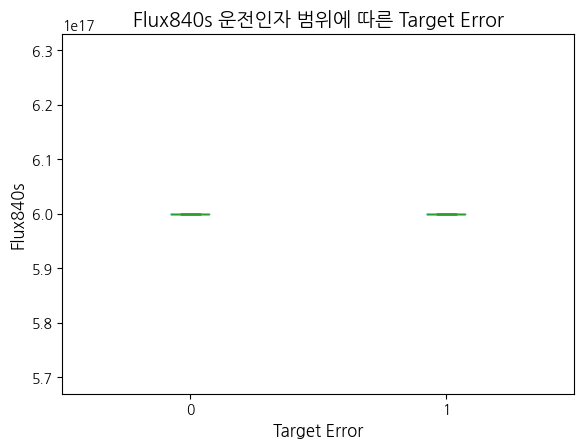

<Figure size 400x300 with 0 Axes>

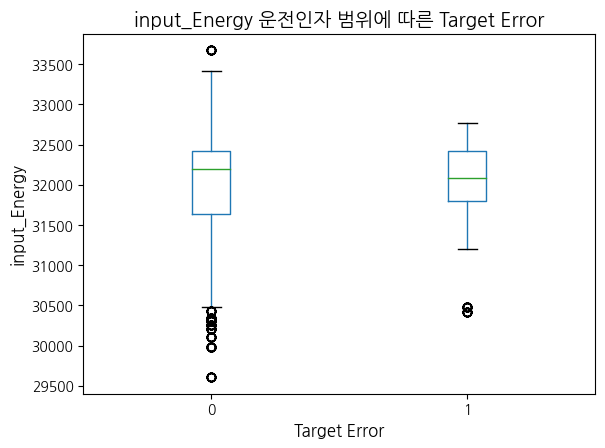

<Figure size 400x300 with 0 Axes>

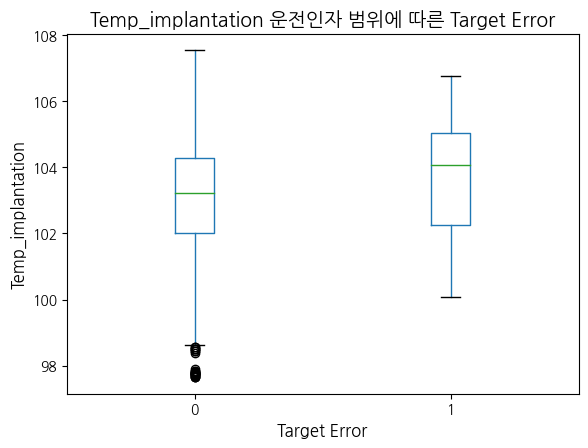

<Figure size 400x300 with 0 Axes>

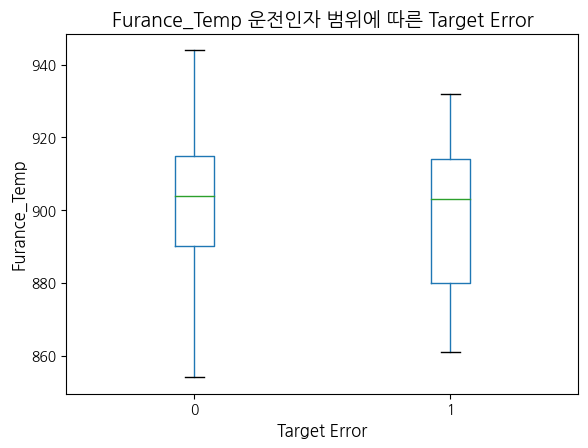

<Figure size 400x300 with 0 Axes>

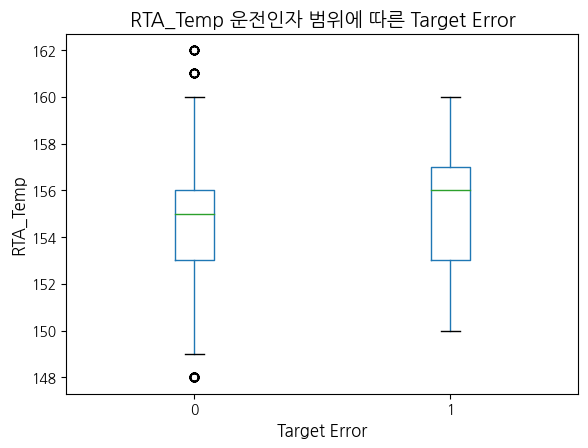

In [29]:
# 분석할 연속형 변수 목록
columns_to_plot = ['Flux60s','Flux90s','Flux160s','Flux480s','Flux840s','input_Energy','Temp_implantation','Furance_Temp','RTA_Temp']

# 각각의 변수에 대해 Target_error에 따른 Box Plot 개별 생성
for column in columns_to_plot:
    plt.figure(figsize=(4, 3))
    data.boxplot(column=column, by='Target_error', grid=False)
    plt.title(f'{column} 운전인자 범위에 따른 Target Error', fontsize=14)  # 제목 글자 크기
    plt.suptitle('')
    plt.xlabel('Target Error', fontsize=12)  # x축 라벨 글자 크기
    plt.ylabel(column, fontsize=12)  # y축 라벨 글자 크기
    plt.xticks(fontsize=10)  # x축 눈금 글자 크기
    plt.yticks(fontsize=10)  # y축 눈금 글자 크기
    plt.show()

In [30]:
data['Flux840s'].unique()
data['Flux840s'].value_counts()
# Flux840s는 값이 모두 같은 것을 확인 가능

6.000000e+17    14422
Name: Flux840s, dtype: int64

# 통계적 검정

In [31]:
from scipy.stats import ttest_ind, levene

# 유의미한 변수 카운트를 위한 리스트 초기화
significant_results = []

# 등분산성 검정 및 T-Test 수행 함수 정의
def perform_t_test_with_variance_check(data, column, alpha=0.05, index=1):
    # 양품과 불량 그룹 나누기
    group_양품 = data[data['Target_error'] == 0][column]
    group_불량 = data[data['Target_error'] == 1][column]

    # 1. 등분산성 검정: Levene’s Test 수행
    stat, p_value_levene = levene(group_양품, group_불량)
    
    # Levene's Test 결과에 따라 T-Test의 등분산 가정 설정
    equal_var = p_value_levene > alpha

    # 2. 2-Sample T-Test 수행
    t_stat, p_value = ttest_ind(group_양품, group_불량, equal_var=equal_var)

    # 3. 귀무가설 기각 여부 출력 및 유의미한 결과 저장
    if p_value < alpha:
        print(f"{index}. {column} - 등분산 여부: {'등분산 가정' if equal_var else '등분산 미가정'}")
        print(f"   T-Statistic: {t_stat}, P-Value: {p_value}")
        print(f"   결과: 귀무가설을 기각합니다. '{column}'의 평균 차이가 통계적으로 유의미합니다.\n")
        # 유의미한 결과 저장
        significant_results.append(column)

# 비교할 운전 조건 리스트
columns_to_test = ['Temp_OXid', 'ppm', 'Pressure', 'Oxid_time',
       'N2_HMDS', 'pressure_HMDS', 'temp_HMDS', 'temp_HMDS_bake', 'time_HMDS_bake', 
       'spin1', 'spin2', 'spin3', 'photoresist_bake', 'temp_softbake', 'time_softbake', 
       'Resolution', 'Energy_Exposure','Wavelength',
       'Temp_Etching', 'Source_Power', 'Selectivity',
       'Flux60s', 'Flux90s', 'Flux160s', 'Flux480s', 'input_Energy','Temp_implantation',
       'Furance_Temp', 'RTA_Temp']

# 각 운전 조건에 대해 등분산성 검정 및 T-Test 수행
for i, column in enumerate(columns_to_test, 1):
    perform_t_test_with_variance_check(data, column, index=i)

# 전체 변수 수 및 통계적으로 유의미한 변수 수 출력
print(f"총 비교한 변수의 개수: {len(columns_to_test)}")
print(f"통계적으로 유의미한 변수의 개수: {len(significant_results)}")

1. Temp_OXid - 등분산 여부: 등분산 미가정
   T-Statistic: 7.041807792411889, P-Value: 3.8769474044196285e-12
   결과: 귀무가설을 기각합니다. 'Temp_OXid'의 평균 차이가 통계적으로 유의미합니다.

2. ppm - 등분산 여부: 등분산 가정
   T-Statistic: 5.15348616139989, P-Value: 2.5906479384761424e-07
   결과: 귀무가설을 기각합니다. 'ppm'의 평균 차이가 통계적으로 유의미합니다.

4. Oxid_time - 등분산 여부: 등분산 미가정
   T-Statistic: -2.111992366653881, P-Value: 0.03497534384565288
   결과: 귀무가설을 기각합니다. 'Oxid_time'의 평균 차이가 통계적으로 유의미합니다.

5. N2_HMDS - 등분산 여부: 등분산 미가정
   T-Statistic: 2.8520933589825193, P-Value: 0.0044425826293750335
   결과: 귀무가설을 기각합니다. 'N2_HMDS'의 평균 차이가 통계적으로 유의미합니다.

8. temp_HMDS_bake - 등분산 여부: 등분산 가정
   T-Statistic: 3.47045455989969, P-Value: 0.0005210980282021735
   결과: 귀무가설을 기각합니다. 'temp_HMDS_bake'의 평균 차이가 통계적으로 유의미합니다.

10. spin1 - 등분산 여부: 등분산 미가정
   T-Statistic: 4.606127343701076, P-Value: 4.732569066836747e-06
   결과: 귀무가설을 기각합니다. 'spin1'의 평균 차이가 통계적으로 유의미합니다.

11. spin2 - 등분산 여부: 등분산 가정
   T-Statistic: 4.2867614010289, P-Value: 1.8247442685306825e-05
   결과: 귀무가설

In [32]:
len(columns_to_test)

29

### 다중 공선성 확인 (확인 결과 의미 없음)

In [13]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from patsy import dmatrices

# 데이터를 불러와서 20개의 유의미한 변수만 포함하도록 필터링
# 유의미한 변수 리스트를 meaningful_vars로 정의

meaningful_vars = [
    'Temp_OXid', 'ppm', 'Oxid_time', 
    'N2_HMDS', 'temp_HMDS_bake', 
    'spin1', 'spin2', 'spin3', 'photoresist_bake', 'temp_softbake', 
    'Wavelength', 'Energy_Exposure', 
    'Temp_Etching', 'Source_Power', 
    'Flux60s', 'Flux90s', 'Flux160s', 'Temp_implantation', 
    'Furance_Temp', 'RTA_Temp','Target'
]

# 유의미한 변수만 선택
df_filtered = data[meaningful_vars]

# VIF 계산
vif_data = pd.DataFrame()
vif_data["Feature"] = df_filtered.columns
vif_data["VIF"] = [variance_inflation_factor(df_filtered.values, i) for i in range(df_filtered.shape[1])]

# VIF 결과 출력
print(vif_data)

              Feature       VIF
0           Temp_OXid  0.956679
1                 ppm  0.998526
2           Oxid_time  1.004669
3             N2_HMDS  1.072728
4      temp_HMDS_bake  1.214944
5               spin1  0.417596
6               spin2  0.719555
7               spin3  0.695491
8    photoresist_bake  1.061306
9       temp_softbake  1.228485
10         Wavelength  0.975846
11    Energy_Exposure  0.699751
12       Temp_Etching  0.493552
13       Source_Power  0.638877
14            Flux60s  1.097805
15            Flux90s  1.244837
16           Flux160s  1.203034
17  Temp_implantation  0.758826
18       Furance_Temp  0.815731
19           RTA_Temp  0.756987
20             Target  1.009630


P-value와 T-statistic 절대값을 동시에 고려:
P-value가 작고 T-statistic의 절대값이 큰 변수를 우선 선택하는 방법을 사용.

P-value가 0.001 이하이면서 T-statistic 절대값이 4 이상인 변수를 선택하는 기준으로 정함.

[Temp_implantation, Source_Power, Temp_OXid, Flux90s, Furance_Temp, ppm, spin1, Temp_softbake, spin2, Temp_Etching 를 고려 예정]

In [14]:
# 필요한 라이브러리 불러오기
import pandas as pd

variables = [
    'Temp_OXid', 'ppm', 'Oxid_time', 
    'N2_HMDS', 'temp_HMDS_bake', 
    'spin1', 'spin2', 'spin3', 'photoresist_bake', 'temp_softbake', 
    'Wavelength', 'Energy_Exposure', 
    'Temp_Etching', 'Source_Power', 
    'Flux60s', 'Flux90s', 'Flux160s', 'Temp_implantation', 
    'Furance_Temp', 'RTA_Temp']


df_양품 = data[data['Target_error'] == 0]
df_불량 = data[data['Target_error'] == 1]

# 결과를 저장할 딕셔너리
optimal_ranges_for_양품 = {}

# 각 변수에 대해 양품과 불량에서 이상치를 제외한 범위 계산
for col in variables:
    # 양품 데이터의 IQR 계산 및 이상치 제거
    Q1_양품 = df_양품[col].quantile(0.25)
    Q3_양품 = df_양품[col].quantile(0.75)
    IQR_양품 = Q3_양품 - Q1_양품
    lower_bound_양품 = Q1_양품 - 1.5 * IQR_양품
    upper_bound_양품 = Q3_양품 + 1.5 * IQR_양품
    df_양품_정상 = df_양품[(df_양품[col] >= lower_bound_양품) & (df_양품[col] <= upper_bound_양품)]
    
    # 불량 데이터의 IQR 계산 및 이상치 제거
    Q1_불량 = df_불량[col].quantile(0.25)
    Q3_불량 = df_불량[col].quantile(0.75)
    IQR_불량 = Q3_불량 - Q1_불량
    lower_bound_불량 = Q1_불량 - 1.5 * IQR_불량
    upper_bound_불량 = Q3_불량 + 1.5 * IQR_불량
    df_불량_정상 = df_불량[(df_불량[col] >= lower_bound_불량) & (df_불량[col] <= upper_bound_불량)]
    
    # 양품과 불량의 정상 범위 최솟값 및 최댓값 계산
    min_양품_정상 = df_양품_정상[col].min()
    max_양품_정상 = df_양품_정상[col].max()
    min_불량_정상 = df_불량_정상[col].min()
    max_불량_정상 = df_불량_정상[col].max()

    # 양품만 나오는 구간 계산
    if max_양품_정상 < min_불량_정상:
        # 양품의 최댓값이 불량의 최솟값보다 작은 경우: 단일 구간
        optimal_ranges_for_양품[col] = [(min_양품_정상, max_양품_정상)]
    elif min_양품_정상 > max_불량_정상:
        # 양품의 최솟값이 불량의 최댓값보다 큰 경우: 단일 구간
        optimal_ranges_for_양품[col] = [(min_양품_정상, max_양품_정상)]
    else:
        # 두 구간이 나오는 경우: 양품과 불량이 일부 겹치는 상황
        optimal_range_양품_lower = (min_양품_정상, min_불량_정상)
        optimal_range_양품_upper = (max_불량_정상, max_양품_정상)
        optimal_ranges_for_양품[col] = [optimal_range_양품_lower, optimal_range_양품_upper]

# 출력
for col, ranges in optimal_ranges_for_양품.items():
    if len(ranges) == 1:  # 구간이 하나만 나오는 경우
        print(f"{col}의 양품만 나오는 구간: ({ranges[0][0]:.2f}, {ranges[0][1]:.2f})")
    else:  # 두 구간이 나오는 경우
        print(f"{col}의 양품만 나오는 구간 (하위 구간): ({ranges[0][0]:.2f}, {ranges[0][1]:.2f})")
        print(f"{col}의 양품만 나오는 구간 (상위 구간): ({ranges[1][0]:.2f}, {ranges[1][1]:.2f})")

Temp_OXid의 양품만 나오는 구간 (하위 구간): (861.79, 871.00)
Temp_OXid의 양품만 나오는 구간 (상위 구간): (1294.70, 1311.32)
ppm의 양품만 나오는 구간 (하위 구간): (20.75, 21.80)
ppm의 양품만 나오는 구간 (상위 구간): (46.07, 50.05)
Oxid_time의 양품만 나오는 구간 (하위 구간): (8.00, 22.00)
Oxid_time의 양품만 나오는 구간 (상위 구간): (235.00, 241.00)
N2_HMDS의 양품만 나오는 구간 (하위 구간): (10.61, 11.08)
N2_HMDS의 양품만 나오는 구간 (상위 구간): (19.21, 21.40)
temp_HMDS_bake의 양품만 나오는 구간 (하위 구간): (192.82, 193.84)
temp_HMDS_bake의 양품만 나오는 구간 (상위 구간): (205.44, 208.07)
spin1의 양품만 나오는 구간 (하위 구간): (493.10, 493.90)
spin1의 양품만 나오는 구간 (상위 구간): (509.17, 509.13)
spin2의 양품만 나오는 구간 (하위 구간): (3886.09, 3879.34)
spin2의 양품만 나오는 구간 (상위 구간): (4106.06, 4156.50)
spin3의 양품만 나오는 구간 (하위 구간): (4859.07, 4849.39)
spin3의 양품만 나오는 구간 (상위 구간): (5172.27, 5194.33)
photoresist_bake의 양품만 나오는 구간 (하위 구간): (4.69, 4.69)
photoresist_bake의 양품만 나오는 구간 (상위 구간): (5.32, 5.35)
temp_softbake의 양품만 나오는 구간 (하위 구간): (88.43, 89.03)
temp_softbake의 양품만 나오는 구간 (상위 구간): (95.48, 95.77)
Wavelength의 양품만 나오는 구간 (하위 구간): (365.00, 365.00)
Wavelength의 

In [15]:
# 각 변수의 범위 조건을 설정
ranges = {
    'Temp_OXid': [(1294.70, 1311.32), (861.79, 871.00)],
    'ppm': [(46.07, 50.05), (20.75, 21.80)],
    'Oxid_time': [(235.00, 241.00), (8.00, 22.00)],
    'N2_HMDS': [(19.21, 21.40)],
    'temp_HMDS_bake': [(205.44, 208.07), (192.82, 193.84)],
    'spin1': [(493.10, 493.90)],
    'spin2': [(4106.06, 4156.50)],
    'spin3': [(5172.27, 5194.33)],
    'photoresist_bake': [(5.32, 5.35)],
    'temp_softbake': [(95.48, 95.77), (88.43, 89.03)],
    'Energy_Exposure': [(111.70, 112.22)],
    'Temp_Etching': [(69.39, 69.78)],
    'Source_Power': [(52.77, 52.83), (49.48, 49.84)],
    'Flux60s': [(2.07e+16, 2.4e+16), (1.97e+15, 2.44e+15)],
    'Flux90s': [(1.9e+17, 2.38e+17)],
    'Flux160s': [(1.21e+18, 1.4e+18)],
    'Temp_implantation': [(106.77, 107.55), (98.64, 100.08)],
    'Furance_Temp': [(932.00, 944.00), (854.00, 861.00)],
    'RTA_Temp': [(149.00, 150.00)]
}

In [16]:
import numpy as np
import random

# 변경된 값들을 저장할 리스트
changes_log = []

# 데이터에 대해 각 변수의 범위가 2개인 경우, 각 값마다 둘 중 하나의 범위를 랜덤으로 골라서 벗어나는 값을 범위 내 값으로 대체
for col, col_ranges in ranges.items():
    for i in range(len(data)):
        # 범위를 벗어나는 값인지 확인
        value = data.at[i, col]
        
        if len(col_ranges) == 2:
            # 범위가 2개인 경우, 두 범위 중 하나라도 충족하면 양품 범위 내에 있다고 판단
            in_range = (col_ranges[0][0] <= value <= col_ranges[0][1]) or (col_ranges[1][0] <= value <= col_ranges[1][1])
        else:
            # 범위가 1개인 경우, 해당 범위 내에 있는지 확인
            in_range = col_ranges[0][0] <= value <= col_ranges[0][1]
        
        # 벗어난 값인 경우
        if not in_range:
            # 각 값마다 범위를 임의로 선택
            lower, upper = random.choice(col_ranges)
            
            # 벗어난 값을 선택된 범위 내 임의의 값으로 대체
            new_value = np.random.uniform(lower, upper)
            data.at[i, col] = new_value
            
            # 변경 내역 기록
            changes_log.append({
                "변수": col,
                "변경 전 값": value,
                "변경 후 값": new_value,
                "대체 범위": (lower, upper)
            })

# 변경 내역 샘플 출력 (처음 10개만)
print("범위를 벗어난 값이 양품 범위 내 랜덤 값으로 대체되었습니다.\n")
for change in changes_log[:10]:  # 처음 10개만 출력
    print(f"변수: {change['변수']}, 변경 전 값: {change['변경 전 값']}, 변경 후 값: {change['변경 후 값']}, 대체 범위: {change['대체 범위']}")

범위를 벗어난 값이 양품 범위 내 랜덤 값으로 대체되었습니다.

변수: Temp_OXid, 변경 전 값: 1214.33, 변경 후 값: 862.8925146755907, 대체 범위: (861.79, 871.0)
변수: Temp_OXid, 변경 전 값: 977.98, 변경 후 값: 1294.9589916838343, 대체 범위: (1294.7, 1311.32)
변수: Temp_OXid, 변경 전 값: 1175.95, 변경 후 값: 1295.1453346445653, 대체 범위: (1294.7, 1311.32)
변수: Temp_OXid, 변경 전 값: 933.47, 변경 후 값: 863.982910921366, 대체 범위: (861.79, 871.0)
변수: Temp_OXid, 변경 전 값: 1140.6, 변경 후 값: 865.1060528449501, 대체 범위: (861.79, 871.0)
변수: Temp_OXid, 변경 전 값: 938.44, 변경 후 값: 870.6858414210463, 대체 범위: (861.79, 871.0)
변수: Temp_OXid, 변경 전 값: 1033.84, 변경 후 값: 1297.5895102872864, 대체 범위: (1294.7, 1311.32)
변수: Temp_OXid, 변경 전 값: 1079.84, 변경 후 값: 868.4749104300112, 대체 범위: (861.79, 871.0)
변수: Temp_OXid, 변경 전 값: 1032.7, 변경 후 값: 862.0176475461578, 대체 범위: (861.79, 871.0)
변수: Temp_OXid, 변경 전 값: 1132.11, 변경 후 값: 866.7549608670132, 대체 범위: (861.79, 871.0)


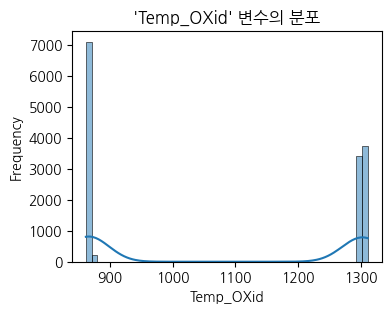

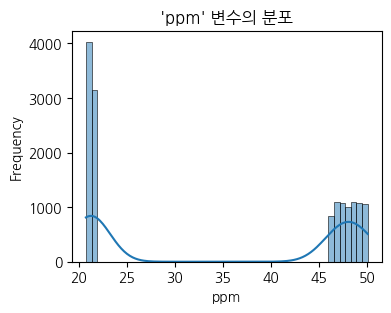

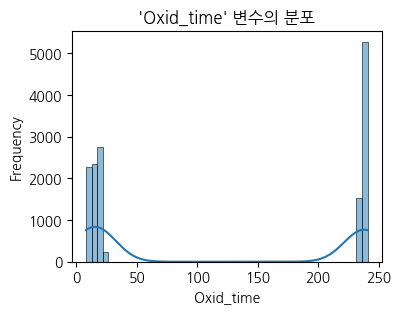

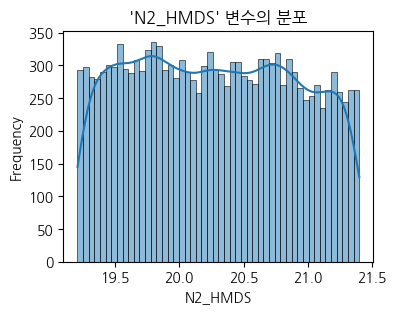

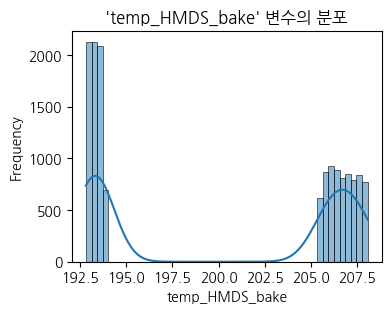

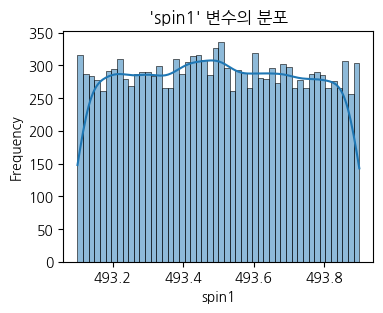

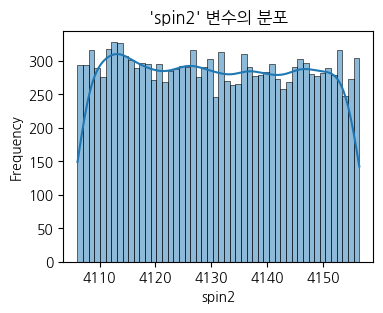

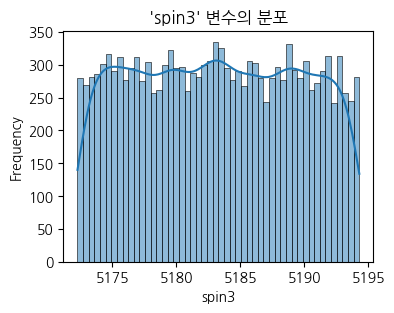

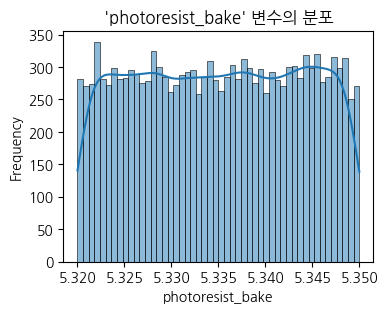

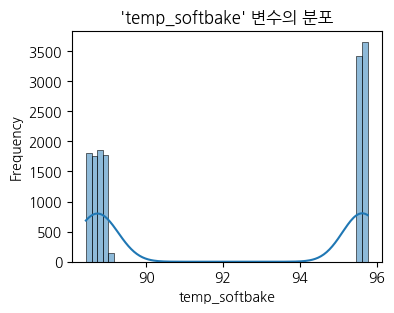

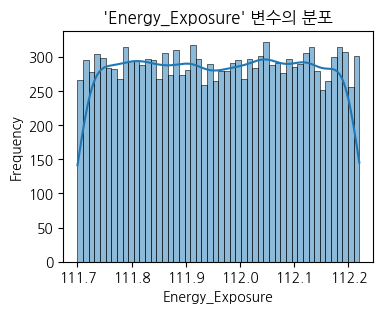

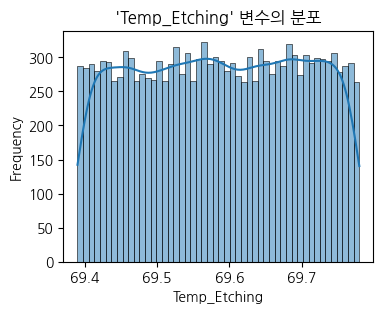

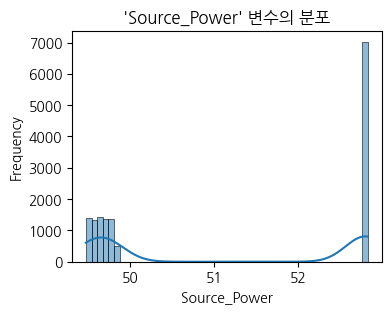

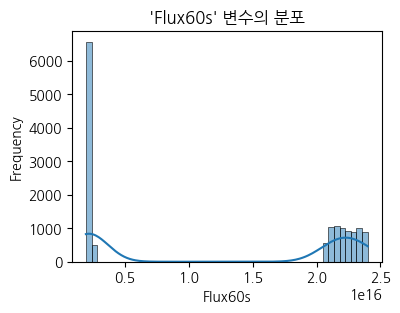

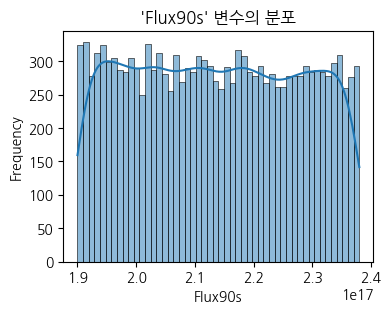

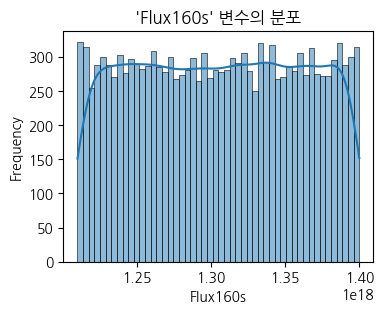

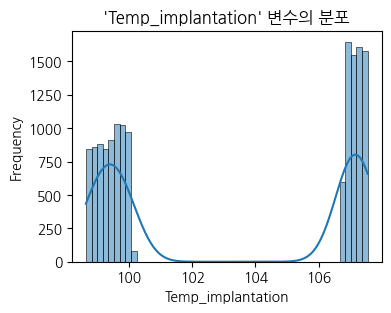

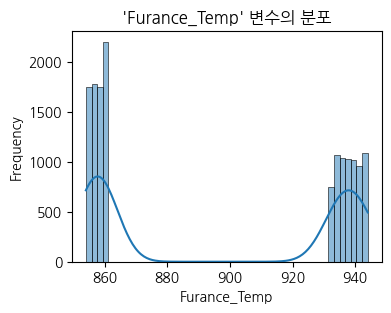

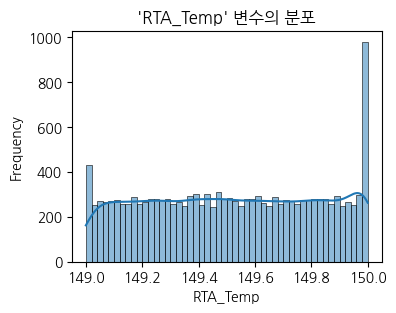

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# 모든 변수에 대해 히스토그램과 KDE 시각화
for col in ranges.keys():
    plt.figure(figsize=(4, 3))
    sns.histplot(data[col], bins=50, kde=True)
    plt.title(f"'{col}' 변수의 분포")
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

In [18]:
data

,No_Die,Ox_Chamber,type,Temp_OXid,ppm,Pressure,Oxid_time,thickness,Lot_Num,Wafer_Num,...,Flux480s,Flux840s,input_Energy,Temp_implantation,Furance_Temp,RTA_Temp,Target,Error_message,Target_error,Path
0,NOLSM32513132,2,0,862.892515,46.505365,0.30,240.655514,712.98,13,28,...,3.010000e+17,6.000000e+17,30795.856,99.654223,854.000000,149.642427,141,none,0,21111
1,NOLSM32513133,2,0,1294.958992,21.007235,0.14,20.612551,714.41,13,29,...,3.030000e+17,6.000000e+17,32135.659,106.957990,936.313259,149.979413,55,none,0,21122
2,NOLSM32513134,2,0,1295.145335,21.687204,0.25,15.757640,710.27,13,30,...,2.980000e+17,6.000000e+17,31057.876,107.431816,857.381676,149.945715,96,none,0,21133
3,NOLSM32513135,2,0,863.982911,47.987245,0.29,13.058343,710.62,13,31,...,3.000000e+17,6.000000e+17,32140.435,107.475493,937.855982,149.803558,105,none,0,21111
4,NOLSM32513136,2,0,865.106053,49.626524,0.20,13.031533,711.70,13,32,...,3.020000e+17,6.000000e+17,31985.989,107.151096,937.989884,149.378189,79,none,0,21122
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14417,NOLSM32528517,3,0,1302.114943,21.183244,0.13,237.197510,711.92,13,23,...,3.000000e+17,6.000000e+17,31877.793,107.125817,858.635324,149.671889,134,none,0,32222
14418,NOLSM32528518,3,0,863.720923,20.800807,0.18,237.254104,696.98,13,24,...,3.000000e+17,6.000000e+17,30107.476,106.810105,943.697362,149.164348,129,none,0,32311
14419,NOLSM32528519,3,0,1295.613634,21.670519,0.08,240.806256,706.11,13,25,...,2.990000e+17,6.000000e+17,32048.298,98.711628,933.646401,149.054508,78,none,0,33111
14420,NOLSM32528520,3,0,865.450158,21.760984,0.38,238.679654,707.33,13,26,...,3.000000e+17,6.000000e+17,31221.150,107.076746,935.737030,149.842300,60,none,0,33222


In [19]:
data.to_csv("찐최종_최적운전조건.csv", index=False)